# House Price Prediction using Machine Learning


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("House_Prediction.csv")

In [3]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,garage_spaces,distance_to_city_center
0,750162,4,3.5,2290.0,2435,3.0,0,4.0,2,1792,498,1983,0,Auburn,WA98002,2.0,13.5
1,655864,2,3.0,2065.0,6037,3.0,0,0.0,2,1716,349,1973,2003,Sammamish,WA98074,1.0,3.6
2,1223255,3,2.0,3821.0,5083,1.0,0,0.0,2,2833,988,1991,0,Auburn,WA98002,1.0,2.7
3,1317016,5,2.0,3864.0,9865,1.0,0,1.0,5,2596,1268,2017,2016,Kirkland,WA98033,3.0,1.6
4,888923,4,3.0,2196.0,7835,3.0,0,1.0,3,1692,504,2012,1995,Kent,WA98032,2.0,21.4


## Understanding the dataset

In [4]:
df.shape

(4004, 17)

In [5]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip', 'garage_spaces',
       'distance_to_city_center'],
      dtype='str')

In [6]:
df.dtypes

price                        int64
bedrooms                     int64
bathrooms                  float64
sqft_living                float64
sqft_lot                     int64
floors                     float64
waterfront                   int64
view                       float64
condition                    int64
sqft_above                   int64
sqft_basement                int64
yr_built                     int64
yr_renovated                 int64
city                           str
statezip                       str
garage_spaces              float64
distance_to_city_center    float64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   price                    4004 non-null   int64  
 1   bedrooms                 4004 non-null   int64  
 2   bathrooms                4002 non-null   float64
 3   sqft_living              4001 non-null   float64
 4   sqft_lot                 4004 non-null   int64  
 5   floors                   4004 non-null   float64
 6   waterfront               4004 non-null   int64  
 7   view                     4001 non-null   float64
 8   condition                4004 non-null   int64  
 9   sqft_above               4004 non-null   int64  
 10  sqft_basement            4004 non-null   int64  
 11  yr_built                 4004 non-null   int64  
 12  yr_renovated             4004 non-null   int64  
 13  city                     4004 non-null   str    
 14  statezip                 4004 non-n

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,garage_spaces,distance_to_city_center
count,4.004000e+03,4004.000000,4002.000000,4001.000000,4004.000000,4004.000000,4004.000000,4001.000000,4004.000000,4004.000000,4004.000000,4004.000000,4004.000000,4002.000000,4004.000000
mean,9.468285e+05,3.981019,2.780110,2535.230192,5963.202048,1.983267,0.050699,2.006498,3.496004,2028.682567,506.088412,1991.064935,305.022977,1.487256,13.040360
std,2.727836e+05,1.432690,1.032404,962.430236,2311.044860,0.708409,0.219410,1.417906,1.120398,806.212799,299.546440,18.089965,720.979537,1.120334,6.841525
min,2.838760e+05,2.000000,1.000000,900.000000,2008.000000,1.000000,0.000000,0.000000,2.000000,590.000000,49.000000,1960.000000,0.000000,0.000000,1.000000
25%,7.245568e+05,3.000000,2.000000,1678.000000,4006.000000,1.500000,0.000000,1.000000,2.000000,1318.750000,269.000000,1976.000000,0.000000,0.000000,7.200000
50%,9.465850e+05,4.000000,3.000000,2523.000000,5894.500000,2.000000,0.000000,2.000000,3.000000,2004.000000,442.000000,1991.000000,0.000000,1.000000,13.100000
75%,1.164314e+06,5.000000,3.500000,3380.000000,7972.250000,2.500000,0.000000,3.000000,5.000000,2675.250000,694.000000,2007.000000,0.000000,2.000000,18.800000
max,1.670973e+06,6.000000,4.500000,4199.000000,9999.000000,3.000000,1.000000,4.000000,5.000000,3954.000000,1454.000000,2022.000000,2022.000000,3.000000,25.000000


# Missing Values

In [9]:
df.isnull().sum()

price                      0
bedrooms                   0
bathrooms                  2
sqft_living                3
sqft_lot                   0
floors                     0
waterfront                 0
view                       3
condition                  0
sqft_above                 0
sqft_basement              0
yr_built                   0
yr_renovated               0
city                       0
statezip                   0
garage_spaces              2
distance_to_city_center    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(4)

In [11]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

bathrooms        2
sqft_living      3
view             3
garage_spaces    2
dtype: int64


# Handling Missing Values

In [12]:
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["sqft_living"] = df["sqft_living"].fillna(df["sqft_living"].median())
df["view"] = df["view"].fillna(df["view"].mode()[0])
df["garage_spaces"] = df["garage_spaces"].fillna(df["garage_spaces"].mode()[0])

In [13]:
print(df.isnull().sum())

price                      0
bedrooms                   0
bathrooms                  0
sqft_living                0
sqft_lot                   0
floors                     0
waterfront                 0
view                       0
condition                  0
sqft_above                 0
sqft_basement              0
yr_built                   0
yr_renovated               0
city                       0
statezip                   0
garage_spaces              0
distance_to_city_center    0
dtype: int64


# Checking Duplicate Values

In [14]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
3999    False
4000     True
4001     True
4002     True
4003     True
Length: 4004, dtype: bool


In [15]:
print(df.duplicated().sum())

4


# Removing Duplicate Rows

In [16]:
df = df.drop_duplicates()

In [17]:
print(df.duplicated().sum())

0


In [18]:
print(df.shape)

(4000, 17)


# Save Clean Dataset

In [19]:
df.to_csv("House_Prediction_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Correlation

In [20]:
df.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,garage_spaces,distance_to_city_center
price,1.000000,0.099127,0.078024,0.924794,-0.015111,0.000294,0.085950,0.084946,0.023169,0.884334,0.591368,0.060911,0.008742,0.040318,-0.070483
bedrooms,0.099127,1.000000,-0.014526,0.002759,0.020030,-0.012900,-0.022263,-0.004493,0.012482,-0.004441,0.019545,0.020407,-0.014628,0.015970,-0.001926
bathrooms,0.078024,-0.014526,1.000000,0.006338,0.017583,-0.006178,-0.022999,-0.003124,-0.008726,0.004934,0.008074,0.006650,-0.015845,-0.010898,0.018063
sqft_living,0.924794,0.002759,0.006338,1.000000,-0.010143,0.001549,-0.007806,0.022675,-0.018199,0.957663,0.634035,0.005093,0.007022,-0.001803,-0.028891
sqft_lot,-0.015111,0.020030,0.017583,-0.010143,1.000000,0.002070,-0.043603,-0.000193,0.005099,-0.009455,-0.007306,-0.004980,-0.004057,-0.002103,0.013827
floors,0.000294,-0.012900,-0.006178,0.001549,0.002070,1.000000,0.009609,0.023636,-0.018948,0.007717,-0.014123,-0.001931,-0.009411,0.002624,-0.007647
waterfront,0.085950,-0.022263,-0.022999,-0.007806,-0.043603,0.009609,1.000000,-0.014720,-0.012596,-0.003438,-0.015470,-0.026725,-0.008968,-0.000773,-0.026430
view,0.084946,-0.004493,-0.003124,0.022675,-0.000193,0.023636,-0.014720,1.000000,-0.011789,0.024711,0.006317,0.002719,-0.001377,-0.010025,-0.039152
condition,0.023169,0.012482,-0.008726,-0.018199,0.005099,-0.018948,-0.012596,-0.011789,1.000000,-0.006335,-0.041825,0.008150,0.001854,0.007517,0.012658
sqft_above,0.884334,-0.004441,0.004934,0.957663,-0.009455,0.007717,-0.003438,0.024711,-0.006335,1.000000,0.385687,0.009029,0.011844,0.005819,-0.024183


#  Exploratory Data Analysis


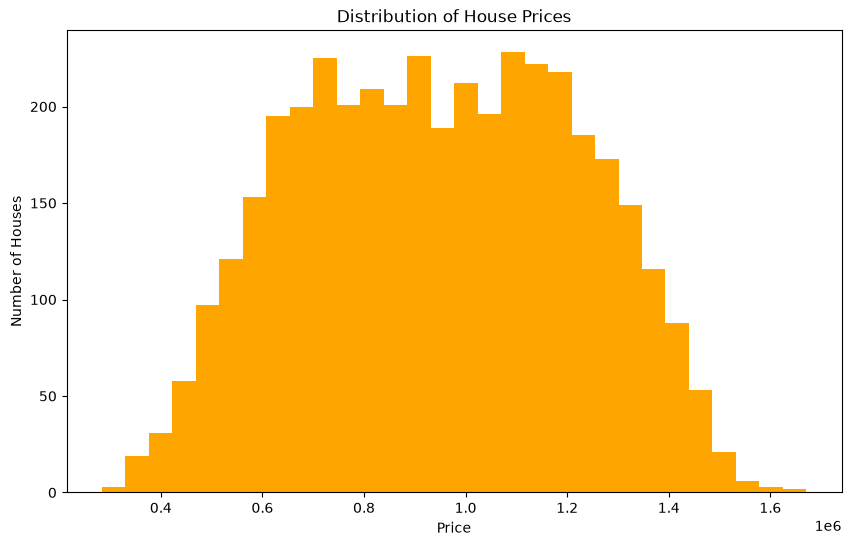

In [21]:
plt.figure(figsize=(10,6))

plt.hist(df["price"], bins=30,color="orange")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

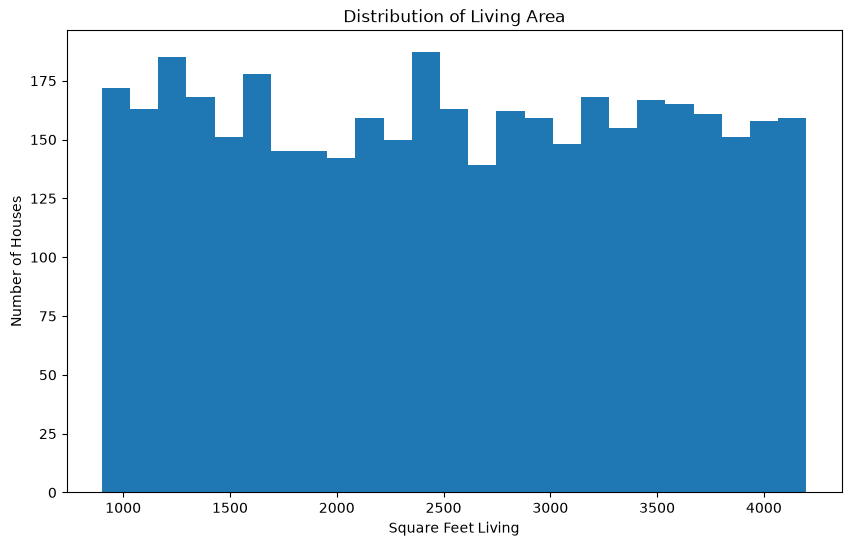

In [22]:
plt.figure(figsize=(10,6))

plt.hist(df["sqft_living"], bins=25)
plt.title("Distribution of Living Area")
plt.xlabel("Square Feet Living")
plt.ylabel("Number of Houses")

plt.show()

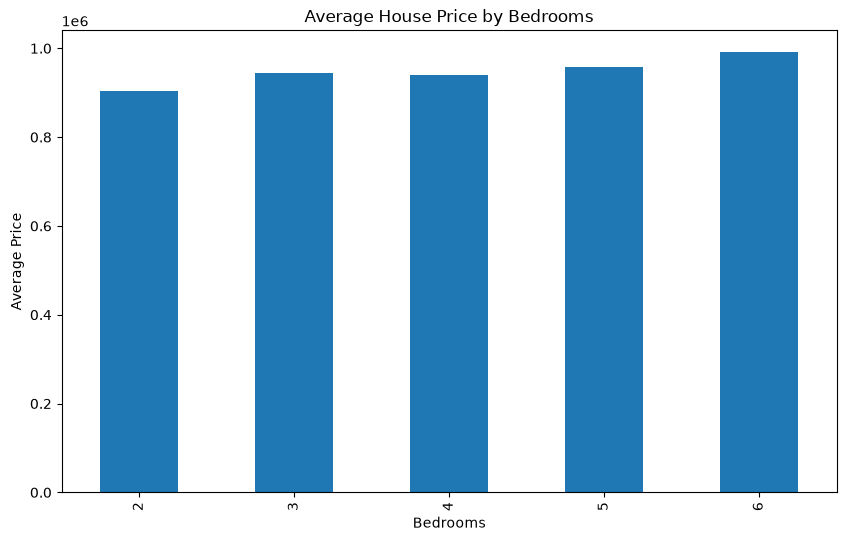

In [23]:
plt.figure(figsize=(10,6))

average_price = df.groupby("bedrooms")["price"].mean()
average_price.plot(kind="bar")
plt.title("Average House Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.show()

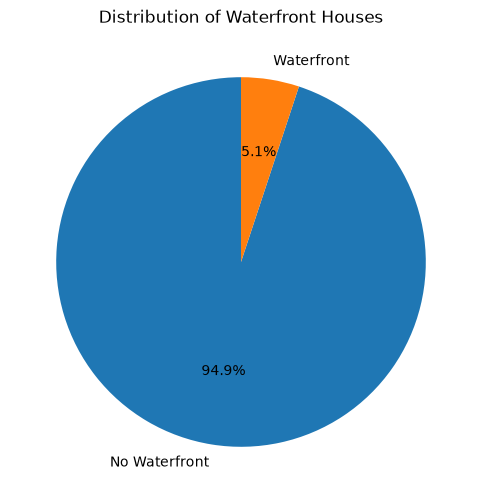

In [24]:
waterfront_count = df["waterfront"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    waterfront_count,
    labels=["No Waterfront", "Waterfront"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Waterfront Houses")

plt.show()

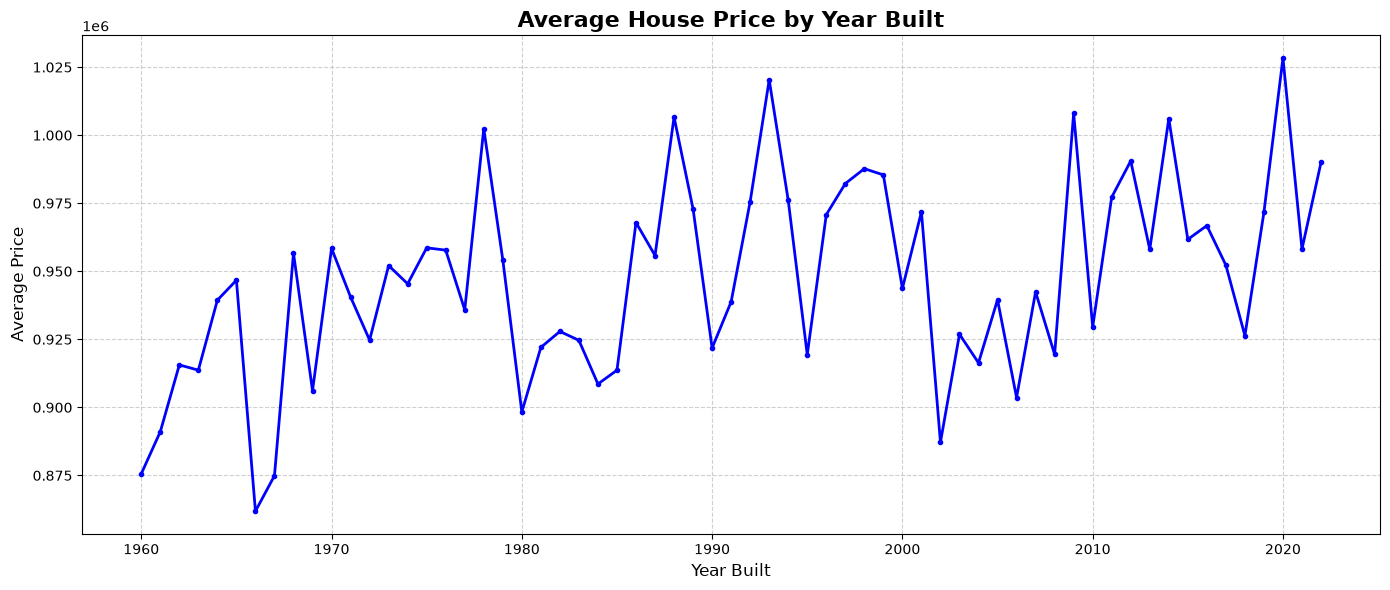

In [25]:
average_price = df.groupby("yr_built")["price"].mean()

plt.figure(figsize=(14,6))

plt.plot(
    average_price.index,
    average_price.values,
    color="blue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.title("Average House Price by Year Built", fontsize=16, fontweight="bold")
plt.xlabel("Year Built", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

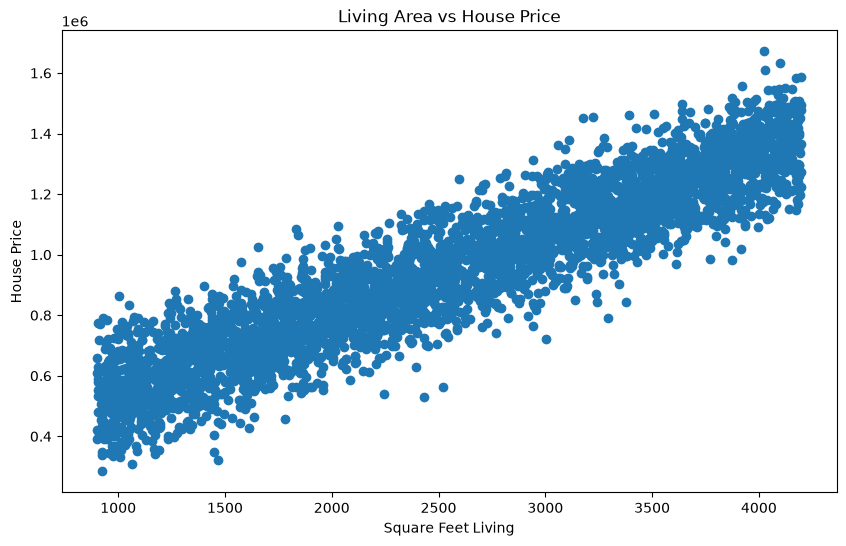

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(df["sqft_living"], df["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Square Feet Living")
plt.ylabel("House Price")

plt.show()

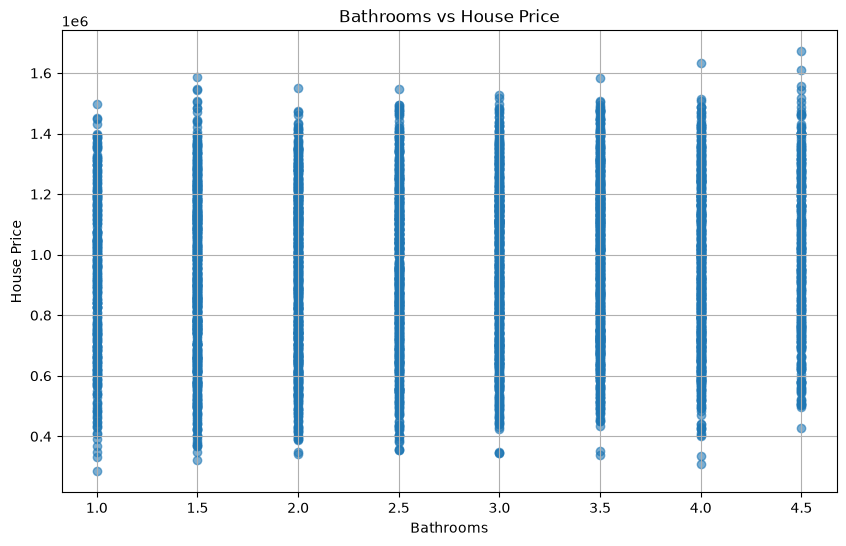

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(df["bathrooms"], df["price"], alpha=0.6)

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("House Price")

plt.grid(True)
plt.show()

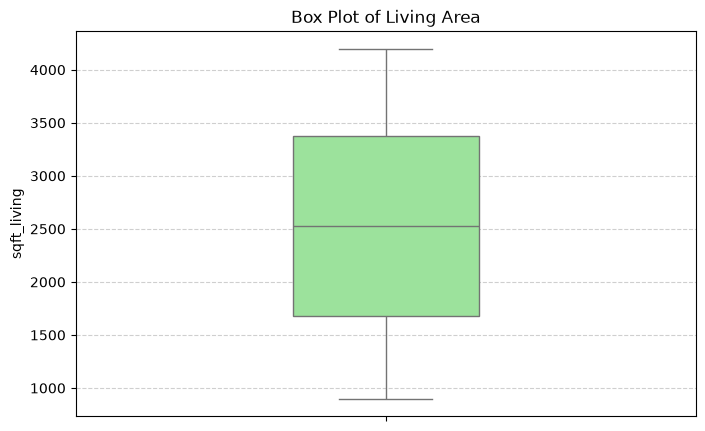

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["sqft_living"],
    color="lightgreen",
    width=0.3,
    showfliers=True
)

plt.title("Box Plot of Living Area")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

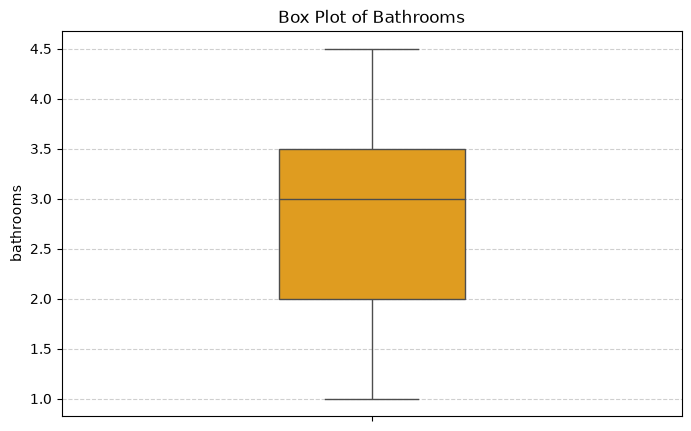

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["bathrooms"],
    color="orange",
    width=0.3,
    showfliers=True
)

plt.title("Box Plot of Bathrooms")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

# Removing Outliers

In [30]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [31]:
print("Shape Before:", df.shape)

Shape Before: (4000, 17)


In [32]:
outliers = df[(df["price"] < lower_limit) | (df["price"] > upper_limit)]

print("Number of Outliers:", len(outliers))

df = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]

Number of Outliers: 0


In [33]:
print("Shape After:", df.shape)

Shape After: (4000, 17)


## Feature Engineering

### Total sqft

In [34]:
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]

In [35]:
print(df[["sqft_above",
          "sqft_basement",
          "total_sqft"]].head())

   sqft_above  sqft_basement  total_sqft
0        1792            498        2290
1        1716            349        2065
2        2833            988        3821
3        2596           1268        3864
4        1692            504        2196


In [36]:
print(df[["total_sqft", "price"]].corr())

            total_sqft    price
total_sqft     1.00000  0.92499
price          0.92499  1.00000


### Total Rooms

In [37]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [226]:
print(df[["total_rooms", "price"]].corr())

             total_rooms  price
total_rooms         1.00   0.16
price               0.16   1.00


## Remove Houses with Price = 0

In [38]:
df = df[df["price"] > 0]

### Feature Selection

In [39]:
X = df.drop(columns=["price"])
y = df["price"]


### Handling Categorical Data

In [40]:
print(X.dtypes)

bedrooms                     int64
bathrooms                  float64
sqft_living                float64
sqft_lot                     int64
floors                     float64
waterfront                   int64
view                       float64
condition                    int64
sqft_above                   int64
sqft_basement                int64
yr_built                     int64
yr_renovated                 int64
city                           str
statezip                       str
garage_spaces              float64
distance_to_city_center    float64
total_sqft                   int64
total_rooms                float64
dtype: object


In [41]:
X = pd.get_dummies(X, drop_first=True)

In [42]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,city_Seattle,statezip_WA 98004,statezip_WA98002,statezip_WA98011,statezip_WA98027,statezip_WA98032,statezip_WA98033,statezip_WA98052,statezip_WA98057,statezip_WA98074
0,4,3.5,2290.0,2435,3.0,0,4.0,2,1792,498,...,False,False,True,False,False,False,False,False,False,False
1,2,3.0,2065.0,6037,3.0,0,0.0,2,1716,349,...,False,False,False,False,False,False,False,False,False,True
2,3,2.0,3821.0,5083,1.0,0,0.0,2,2833,988,...,False,False,True,False,False,False,False,False,False,False
3,5,2.0,3864.0,9865,1.0,0,1.0,5,2596,1268,...,False,False,False,False,False,False,True,False,False,False
4,4,3.0,2196.0,7835,3.0,0,1.0,3,1692,504,...,False,False,False,False,False,True,False,False,False,False


In [43]:
print("Shape after encoding:", X.shape)

Shape after encoding: (4000, 34)


In [44]:
import joblib

joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model columns saved successfully!")

Model columns saved successfully!


## Train-Test-Split

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3200, 34)
X_test : (800, 34)
y_train: (3200,)
y_test : (800,)


# Linear Regression

### Create model

In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Train the model

In [47]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [48]:
pd.options.display.float_format = '{:,.2f}'.format

### Prediction

In [49]:
predictions = model.predict(X_test)

predictions_df = pd.DataFrame(predictions, columns=["Predicted Price"])
print(predictions_df.head(10))

   Predicted Price
0     1,108,383.86
1     1,122,146.38
2     1,105,553.16
3     1,160,295.87
4       789,077.42
5       489,998.29
6       710,210.80
7       950,850.24
8       957,899.79
9     1,188,983.75


In [50]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)


,Actual Price,Predicted Price
0,1127537,"1,108,383.86"
1,1129999,"1,122,146.38"
2,997828,"1,105,553.16"
3,1243854,"1,160,295.87"
4,869901,"789,077.42"
5,470212,"489,998.29"
6,796733,"710,210.80"
7,988801,"950,850.24"
8,942199,"957,899.79"
9,1282189,"1,188,983.75"


### Model Evaluation

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [107]:
lr_mae = mean_absolute_error(y_test, predictions)
lr_mse = mean_squared_error(y_test, predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", lr_mae)
print("Mean Squared Error (MSE):", lr_mse)
print("Root Mean Squared Error (RMSE):",lr_rmse)
print("R² Score:", lr_r2)

Mean Absolute Error (MAE): 57483.15812170796
Mean Squared Error (MSE): 6386900627.218166
Root Mean Squared Error (RMSE): 79918.08698422508
R² Score: 0.9138557775984462


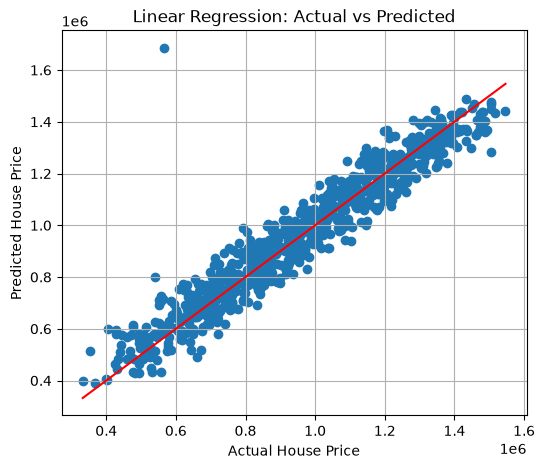

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

In [98]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.head(10)

,Feature,Coefficient
0,bedrooms,"5,033.79"
1,bathrooms,"8,057.48"
2,sqft_living,770.57
3,sqft_lot,-0.21
4,floors,"-3,047.38"
5,waterfront,"121,542.24"
6,view,"12,109.73"
7,condition,"9,078.31"
8,sqft_above,-176.10
9,sqft_basement,-160.70


# Decision Tree 

In [55]:
from sklearn.tree import DecisionTreeRegressor

### Create Model

In [56]:
dt_model = DecisionTreeRegressor(random_state=42)

### Train the model

In [57]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### Predict

In [58]:
dt_predictions = dt_model.predict(X_test)

### Evaluate

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE : 93715.02375
MSE : 14059908840.30875
RMSE: 118574.48646445302
R² Score: 0.8103649978639698


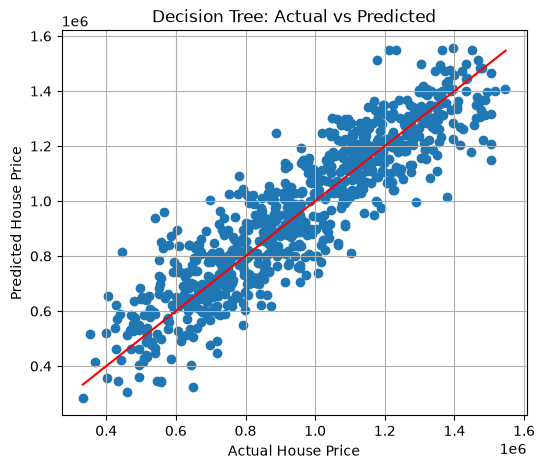

In [60]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, dt_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor

### Create Model

In [62]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### Train the model

In [63]:
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Predict

In [64]:
rf_predictions = rf_model.predict(X_test)

### Evaluate

In [65]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 63859.26920062501
MSE : 6406895144.168078
RMSE: 80043.08305011794
R² Score: 0.9135860987329876


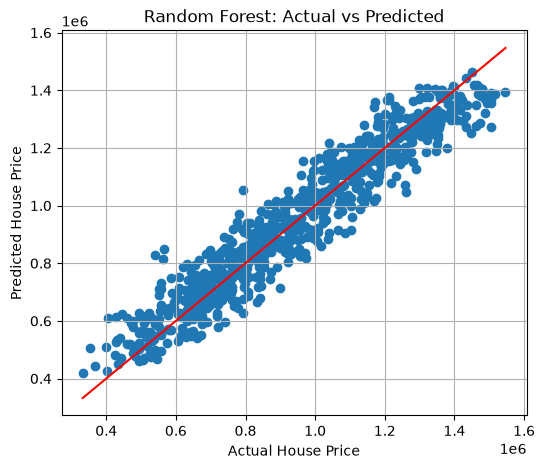

In [66]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

### Feature Importance

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,sqft_living,0.54
14,total_sqft,0.33
15,total_rooms,0.02
10,yr_built,0.01
13,distance_to_city_center,0.01
26,statezip_WA98002,0.01
3,sqft_lot,0.01
8,sqft_above,0.01
9,sqft_basement,0.01
5,waterfront,0.01


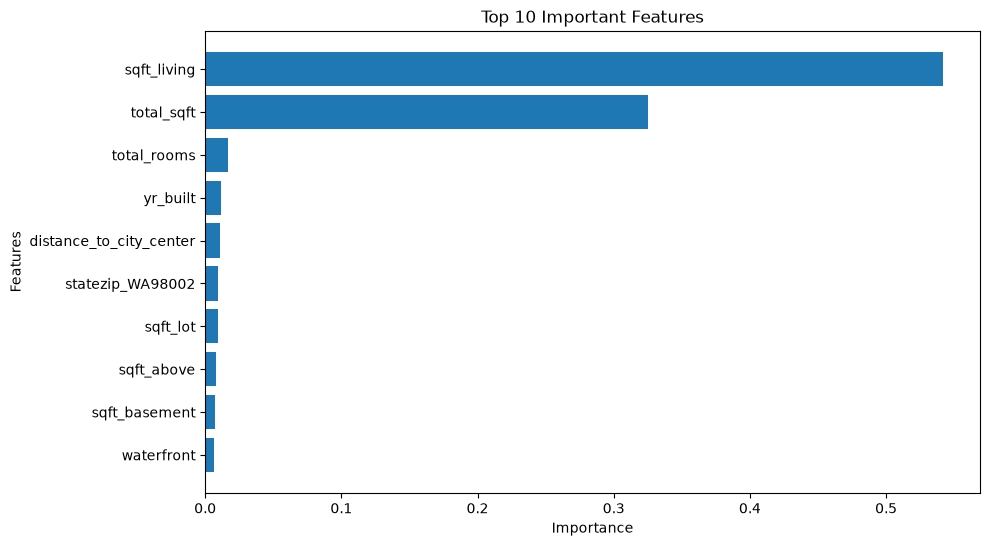

In [68]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# KNN

In [69]:
from sklearn.neighbors import KNeighborsRegressor

### Create Model

In [70]:
knn_model = KNeighborsRegressor(n_neighbors=5)

### Train the model

In [71]:
knn_model.fit(X_train, y_train)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### Predict

In [72]:
knn_predictions = knn_model.predict(X_test)

### Evaluate

In [74]:
knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Results")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Results
MAE : 89364.0375
MSE : 12471788325.8629
RMSE: 111677.16116495305
R² Score: 0.8317849971377772


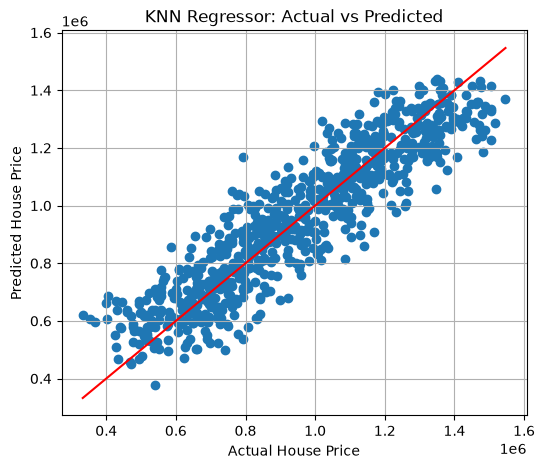

In [75]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, knn_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("KNN Regressor: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Support Vector Regressor

In [76]:
from sklearn.svm import SVR

### Create Model

In [77]:
svr_model = SVR(kernel="rbf")

### Train The Model

In [78]:
svr_model.fit(X_train, y_train)

print("SVR Model trained successfully!")

SVR Model trained successfully!


### Predict

In [79]:
svr_predictions = svr_model.predict(X_test)

### Evaluate

In [80]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("SVR Results")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

SVR Results
MAE : 231193.13703676724
MSE : 74130350585.12437
RMSE: 272268.8938992561
R² Score: 0.00015644829415339956


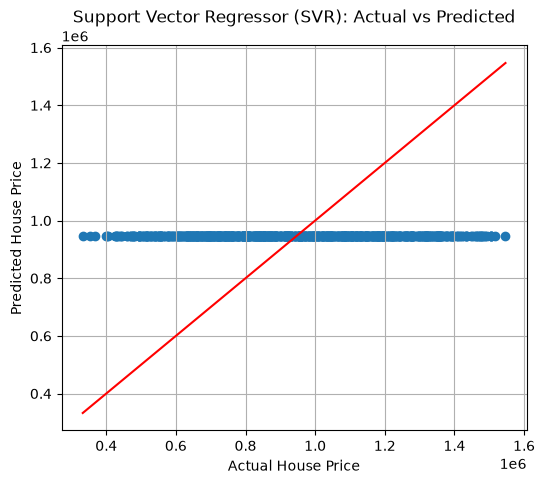

In [81]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, svr_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Support Vector Regressor (SVR): Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Comparison

In [82]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE": [mae, dt_mae, rf_mae, knn_mae, svr_mae],
    "RMSE": [rmse, dt_rmse, rf_rmse, knn_rmse, svr_rmse],
    "R² Score": [r2, dt_r2, rf_r2, knn_r2, svr_r2]
})

display(comparison)

,Algorithm,MAE,RMSE,R² Score
0,Linear Regression,"57,483.16","79,918.09",0.91
1,Decision Tree,"93,715.02","118,574.49",0.81
2,Random Forest,"63,859.27","80,043.08",0.91
3,KNN,"89,364.04","111,677.16",0.83
4,SVR,"231,193.14","272,268.89",0.00


In [84]:
print(X.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'garage_spaces', 'distance_to_city_center',
       'total_sqft', 'total_rooms', 'city_Bellevue', 'city_Bothell',
       'city_Issaquah', 'city_Kent', 'city_Kirkland', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_Seattle', 'statezip_WA 98004',
       'statezip_WA98002', 'statezip_WA98011', 'statezip_WA98027',
       'statezip_WA98032', 'statezip_WA98033', 'statezip_WA98052',
       'statezip_WA98057', 'statezip_WA98074'],
      dtype='str')


# Best Model Selection

In [99]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Algorithm    Linear Regression
MAE                  57,483.16
RMSE                 79,918.09
R² Score                  0.91
Name: 0, dtype: object


# Cross Validation

In [100]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())

Cross Validation Scores:
[0.93098366 0.91178204 0.93255452 0.93957699 0.92583086]

Average R² Score: 0.9281456140901438


# Hyperparameter Tuning

### Random Forest Hyperparameter Tuning

In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest Model
rf_model = RandomForestRegressor(random_state=42)

# Parameters to Test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Display Best Parameters
print("Best Parameters")
print(grid_search.best_params_)

# Display Best Cross Validation Score
print("\nBest Cross Validation Score")
print(round(grid_search.best_score_, 4))

# Best Model
best_rf = grid_search.best_estimator_

# Prediction using Tuned Model
opt_rf_prediction = best_rf.predict(X_test)

# Evaluation Metrics
opt_rf_mae = mean_absolute_error(y_test, opt_rf_prediction)
opt_rf_rmse = np.sqrt(mean_squared_error(y_test, opt_rf_prediction))
opt_rf_r2 = r2_score(y_test, opt_rf_prediction)

print("\n Optimized Random Forest Performance")
print(f"MAE      : {opt_rf_mae:,.2f}")
print(f"RMSE     : {opt_rf_rmse:,.2f}")
print(f"R² Score : {opt_rf_r2:.4f}")

Best Parameters
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Score
0.9051

 Optimized Random Forest Performance
MAE      : 63,736.52
RMSE     : 80,030.54
R² Score : 0.9136


## Comparison Table after  model tuning

In [118]:
import pandas as pd

comparison_after_tuning = pd.DataFrame({

    "Algorithm":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest",
        "KNN",
        "SVR"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        opt_rf_mae,
        knn_mae,
        svr_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        opt_rf_rmse,
        knn_rmse,
        svr_rmse
    ],

    "R² Score":[
        lr_r2,
        dt_r2,
        rf_r2,
        opt_rf_r2,
        knn_r2,
        svr_r2
    ]

})

comparison_after_tuning = comparison_after_tuning.sort_values(
    by=["R² Score", "RMSE", "MAE"],
    ascending=[False, True, True]
)

comparison_after_tuning = comparison_after_tuning.round(2)

display(comparison_after_tuning)

,Algorithm,MAE,RMSE,R² Score
0,Linear Regression,"57,483.16","79,918.09",0.91
3,Optimized Random Forest,"63,736.52","80,030.54",0.91
2,Random Forest,"63,859.27","80,043.08",0.91
4,KNN,"89,364.04","111,677.16",0.83
1,Decision Tree,"93,715.02","118,574.49",0.81
5,SVR,"231,193.14","272,268.89",0.00


# Select Best Model After Tuning

In [119]:
best_model = comparison_after_tuning.iloc[0]

print("Best Model Selected")

print(best_model)

Best Model Selected
Algorithm    Linear Regression
MAE                  57,483.16
RMSE                 79,918.09
R² Score                  0.91
Name: 0, dtype: object


## Save Best Model

In [120]:
import joblib

joblib.dump(model, "Best_House_Price_Model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [121]:
loaded_model = joblib.load("Best_House_Price_Model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


## Predict House Price for New Data

In [122]:
new_house = X.iloc[[10]]

predicted_price = loaded_model.predict(new_house)
print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

print("Actual Price: ₹{:,.2f}".format(y.iloc[10]))

Predicted House Price: ₹1,314,912.61
Actual Price: ₹1,317,431.00


In [123]:
new_house = X.iloc[[8]]

predicted_price = loaded_model.predict(new_house)
print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

print("Actual Price: ₹{:,.2f}".format(y.iloc[8]))

Predicted House Price: ₹826,276.34
Actual Price: ₹804,532.00
